# Projet 9 — Analysez les ventes d'une librairie avec Python
##Analyses statistiques / Tests statistiques

In [ ]:
#Import des bibliothèque NumPy, Pandas et Matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1) Import drive from google.colab
from google.colab import drive
drive.mount('/content/drive')

# 2) Charger les CSV BRUTS
df_products = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P9/data/products.csv", sep=";")
df_customers = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P9/data/customers.csv", sep=";")
df_transactions = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P9/data/Transactions.csv", sep=";")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1046/1197497098.py:8: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P9/data/Transactions.csv", sep=";")


In [ ]:
df_final = pd.read_csv("/content/drive/MyDrive/df_final_clean.csv")

Les données nettoyées et fusionnées ont été exportées afin d’être réutilisées dans ce notebook dédié aux tests statistiques.

In [ ]:
df_final.head()
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id_prod      687534 non-null  object 
 1   date         687534 non-null  object 
 2   session_id   687534 non-null  object 
 3   client_id    687534 non-null  object 
 4   sex          687534 non-null  object 
 5   birth        687534 non-null  int64  
 6   price        687534 non-null  float64
 7   categ        687534 non-null  int64  
 8   age          687534 non-null  int64  
 9   year_month   687534 non-null  object 
 10  categ_label  687534 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 57.7+ MB


Les données utilisées dans ce notebook proviennent du notebook d’analyse business.
Le fichier nettoyé et fusionné a été exporté puis réutilisé pour les analyses statistiques.

###CA par client

In [ ]:
# CA par client
ca_client = df_final.groupby("client_id")["price"].sum()
ca_client.describe()

,price
count,8600.000000
mean,1398.565477
std,5202.771679
min,6.310000
25%,562.730000
50%,1045.695000
75%,1797.720000
max,326039.890000


Identification des clients atypiques

In [ ]:
#Afficher les plus gros clients
ca_client.sort_values(ascending=False).head(10)

,price
client_id,
c_1609,326039.89
c_4958,290227.03
c_6714,153918.60
c_3454,114110.57
c_1570,5285.82
c_3263,5276.87
c_2140,5260.18
c_2899,5214.05
c_7319,5155.77


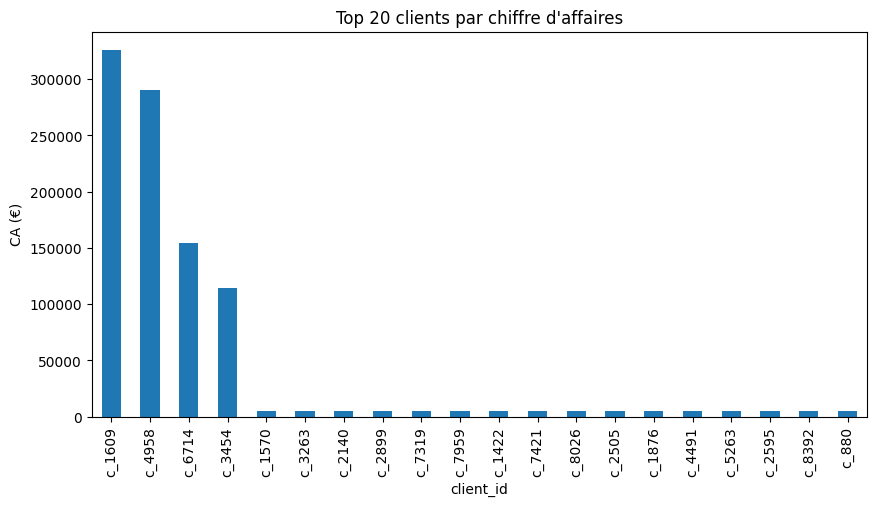

In [ ]:
#analyse visual des clients athypiques
plt.figure(figsize=(10,5))

ca_client.sort_values(ascending=False).head(20).plot(kind="bar")

plt.title("Top 20 clients par chiffre d'affaires")
plt.ylabel("CA (€)")
plt.show()

L’analyse du chiffre d’affaires par client montre que quatre clients présentent des montants exceptionnellement élevés par rapport au reste de la clientèle. Ces profils atypiques peuvent correspondre à des clients BtoB.

In [ ]:
#creation de liste
clients_btob = ["c_1609", "c_4958", "c_6714", "c_3454"]

In [ ]:
# data frame sans les clients btob
df_sans_btob = df_final[~df_final["client_id"].isin(clients_btob)].copy()

In [ ]:
#verification
df_sans_btob["client_id"].isin(clients_btob).sum()

np.int64(0)

Afin d’éviter qu’ils biaisent les analyses statistiques, ils ont été exclus des tests statistiques réalisés par la suite.

# Tests statistiques

* Sexe ↔ catégorie
* Âge ↔ montant
* Âge ↔ fréquence
* Âge ↔ panier moyen
* Âge ↔ catégorie

In [ ]:
#règle à respecter
#qualitatif vs qualitatif → Khi²
#quantitatif vs quantitatif → corrélation
#qualitatif vs quantitatif → ANOVA

In [ ]:
import scipy.stats as stats

###1. Est-ce que les hommes et les femmes achètent les mêmes catégories?

 Type de test
* sexe = catégorie (m / f) → qualitatif
* catégorie produit = 0 / 1 / 2 → qualitatif

  on utilise : test du Khi² pour savoir s'il y a un lien entre les deux variables



Étape 1 — tableau de comptage

In [ ]:
#creation table
table = pd.crosstab(df_sans_btob["sex"], df_sans_btob["categ"])
table

categ,0,1,2
sex,,,
f,200793,115721,16980
m,186488,104884,15868


In [ ]:
#test Khi2
chi2, p, dof, expected = stats.chi2_contingency(table)

print("p-value :", p)

p-value : 1.1955928116587024e-05


In [ ]:
#La p-value est extrêmement faible, bien inférieure à 0.05. ce qui indique que le résultat est statistiquement significatif.
#un lien de corrélation exsiste entre sexe et catégorie

In [ ]:
expected

array([[201574.89662481, 114822.13191434,  17096.97146086],
       [185706.10337519, 105782.86808566,  15751.02853914]])

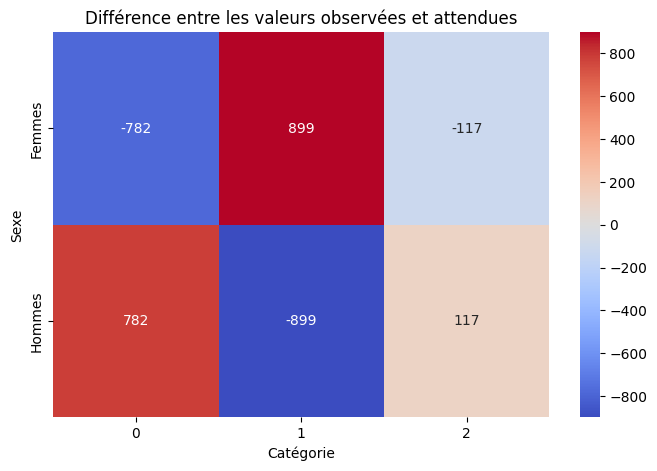

In [ ]:
# différence entre observé et attendu
# différence entre observé et attendu
diff = table - expected

plt.figure(figsize=(8,5))

sns.heatmap(
    diff,
    annot=True,
    fmt=".0f",   # enlève notation scientifique
    cmap="coolwarm",
    center=0,
    xticklabels=["0", "1", "2"],
    yticklabels=["Femmes", "Hommes"]
)

plt.title("Différence entre les valeurs observées et attendues")
plt.xlabel("Catégorie")
plt.ylabel("Sexe")

plt.show()

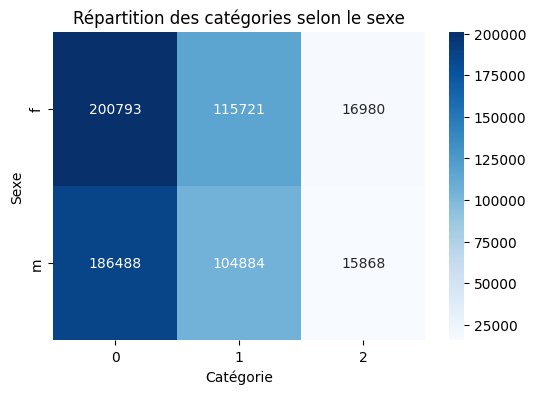

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    table,
    annot=True,
    fmt="d",
    cmap="Blues")

plt.title("Répartition des catégories selon le sexe")
plt.xlabel("Catégorie")
plt.ylabel("Sexe")

plt.show()

répartition relativement équilibrée

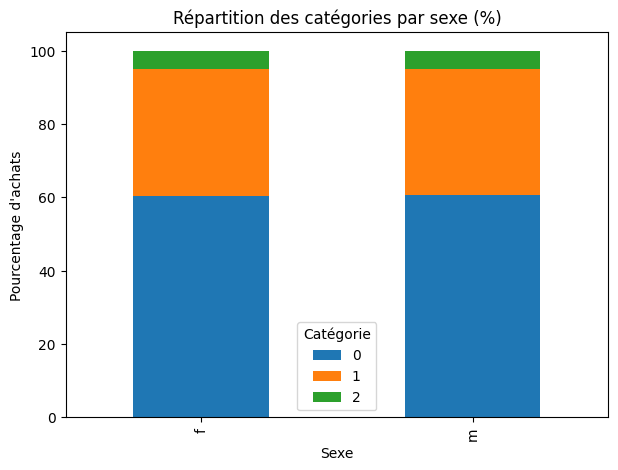

In [ ]:
# Conversion en pourcentage
table_pct = table.div(table.sum(axis=1), axis=0) * 100

# Graphique
table_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5))

plt.title("Répartition des catégories par sexe (%)")
plt.xlabel("Sexe")
plt.ylabel("Pourcentage d'achats")

plt.legend(title="Catégorie")

plt.show()

Le test du Khi² indique une relation statistiquement significative entre le sexe et la catégorie de produits achetés.
Cependant, les écarts observés restent faibles visuellement, comme le montre la heatmap, ce qui suggère des comportements d’achat globalement similaires entre hommes et femmes.

### 2. Est-ce que l’âge influence combien un client dépense ?
Type de variables


* âge → quantitatif
* montant → quantitatif

on utilise : test = corrélation

In [ ]:
#La corrélation est proche de 0 → pas de relation
#La corrélation est positive +1 → les variables évoluent dans le même sens
#La corrélation est négative -1 → elles évoluent en sens inverse

Étape 1 — calcul corrélation

In [ ]:
current_year = 2023
age_client = current_year - df_sans_btob.groupby('client_id')['birth'].first()

ca_client = df_sans_btob.groupby("client_id")["price"].sum()

common_clients = age_client.index.intersection(ca_client.index)
age_client_for_corr = age_client.loc[common_clients]
ca_client_for_corr = ca_client.loc[common_clients]

corr = ca_client_for_corr.corr(age_client_for_corr)
print("Corrélation :", corr)

Corrélation : -0.18756654332685185


La corrélation entre l’âge et le montant total des achats est  faible (-0.19), ce qui indique l’absence de relation entre ces deux variables.
Les jeunes et les plus âgés dépensent à peu près pareil.

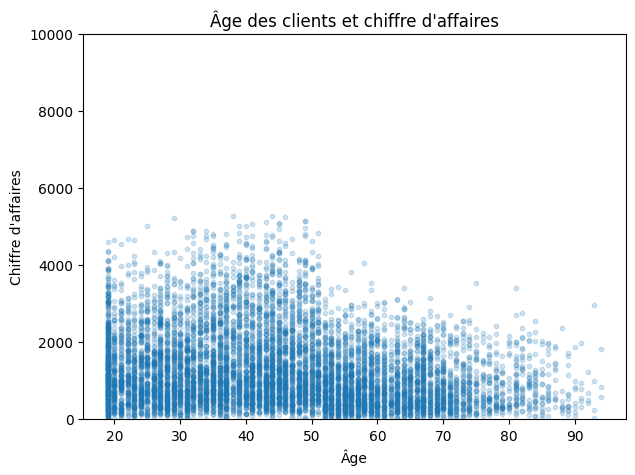

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    age_client,
    ca_client,
    alpha=0.2,
    s=10)

plt.ylim(0, 10000)

plt.title("Âge des clients et chiffre d'affaires")
plt.xlabel("Âge")
plt.ylabel("Chiffre d'affaires")

plt.show()


#Une tendance :

#diagonale montante = corrélation positive
#diagonale descendante = corrélation négative
#nuage dispersé = pas de relation

Le nuage de points montre une forte dispersion des données, sans tendance linéaire marquée entre l’âge et le chiffre d’affaires.
Une légère diminution des montants peut être observée chez les clients les plus âgés, mais la relation reste très faible.

### 3. Est-ce que certaines tranches d’âge achètent plus souvent ?

Relation entre l’âge et la fréquence d’achat
* âge → quantitatif
* fréquence → quantitatif


 test = corrélation


In [ ]:
freq_client = df_sans_btob.groupby("client_id")["session_id"].nunique()

In [ ]:
# Corrélation avec l'âge
corr = freq_client.corr(age_client)
print("Corrélation :", corr)

Corrélation : 0.16449131101203118


Interprétation de la corrélation entre l’âge et la fréquence d’achat

Nous avons calculé la corrélation entre l’âge des clients et leur fréquence d’achat (nombre de sessions).

Le coefficient obtenu est de **0.16**.

Cela indique une **corrélation positive très faible** : les clients plus âgés ont légèrement tendance à acheter plus souvent, mais le lien reste faible.

On peut donc conclure que l’âge influence peu la fréquence d’achat des clients.

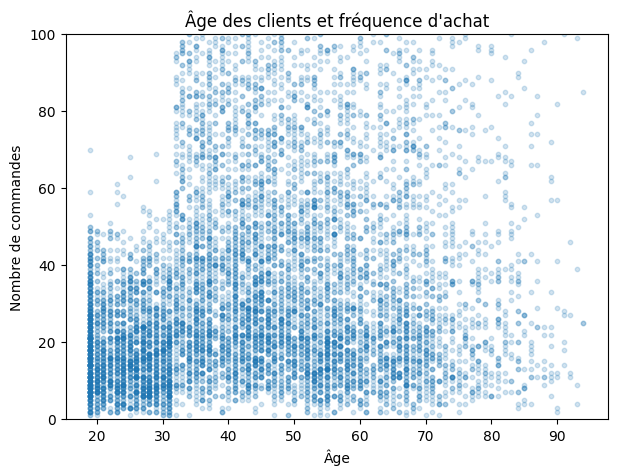

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    age_client,
    freq_client,
    alpha=0.2,
    s=10)

plt.ylim(0, 100)

plt.title("Âge des clients et fréquence d'achat")
plt.xlabel("Âge")
plt.ylabel("Nombre de commandes")

plt.show()

Le nuage de points montre une forte dispersion des données, sans tendance claire entre l’âge des clients et la fréquence d’achat.
Une légère concentration de fréquences plus élevées est observée chez les clients entre 30 et 60 ans, mais la relation reste très faible

### 4. Est-ce que l’âge influence le montant moyen d’un panier ?

* âge → quantitatif
* panier moyen → quantitatif

 test = corrélation

In [ ]:
panier_moyen = ca_client / freq_client

# Corrélation avec l'âge
corr = panier_moyen.corr(age_client)
print("Corrélation :", corr)

Corrélation : -0.616549068667175


Le coefficient de corrélation est de -0.62 environ, ce qui montre une corrélation négative modérée : les clients plus âgés ont tendance à avoir un panier moyen légèrement plus faible.

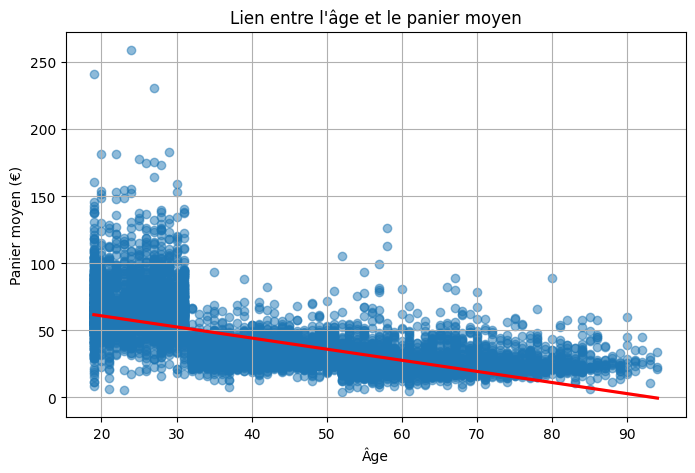

In [ ]:
panier_client_data = pd.DataFrame({'age': age_client, 'panier_moyen': panier_moyen})

plt.figure(figsize=(8,5))

sns.regplot(
    data=panier_client_data,
    x="age",
    y="panier_moyen",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"})

plt.title("Lien entre l'âge et le panier moyen")
plt.xlabel("Âge")
plt.ylabel("Panier moyen (€)")
plt.grid(True)

plt.show()

Le nuage de points met en évidence une tendance décroissante : lorsque l’âge augmente, le panier moyen tend à diminuer. Néanmoins, la dispersion des données montre que d’autres facteurs peuvent également intervenir.

### 5. Est-ce que l’âge moyen change selon les catégories ?

* âge → quantitatif
* catégorie → qualitative

 test = Anova


| Situation       | Test        |
| --------------- | ----------- |
| nombre ↔ nombre | corrélation |
| groupe ↔ nombre | ANOVA       |
| groupe ↔ groupe | Khi²        |


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
current_year = 2023
df_sans_btob['age'] = current_year - df_sans_btob['birth']

# Modèle ANOVA
model = ols('age ~ C(categ)', data=df_sans_btob).fit()

In [ ]:
# Test ANOVA
anova = sm.stats.anova_lm(model, typ=2)

anova

,sum_sq,df,F,PR(>F)
C(categ),1.361128e+07,2.0,39705.519693,0.0
Residual,1.098231e+08,640731.0,NaN,NaN


In [ ]:
# La p-value obtenue est inférieure à 0.05.
# Cela indique qu’il existe une relation entre l’âge des clients
# et les catégories de produits achetées.
# Certaines catégories semblent donc être davantage plus achetées selon l’âge des clients.

In [ ]:
# Le test ANOVA permet de vérifier s’il existe une différence d’âge entre les catégories de produits.

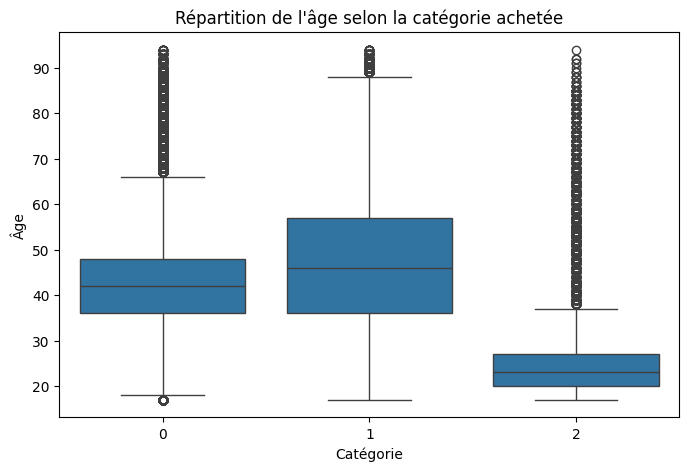

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_final,
    x="categ",
    y="age"
)

plt.title("Répartition de l'âge selon la catégorie achetée")
plt.xlabel("Catégorie")
plt.ylabel("Âge")

plt.show()

Le boxplot montre que certaines catégories sont associées à des groupes d’âge différents. La catégorie 2 semble davantage achetée par une population plus jeune.

In [ ]:
current_year = 2023
df_sans_btob['age'] = current_year - df_sans_btob['birth']
df_sans_btob.groupby("categ")["age"].mean()

,age
categ,
0,44.794563
1,48.650035
2,26.965508


In [ ]:
# Le calcul des moyennes par catégorie permet de comprendre quelles catégories sont associées
#aux clients les plus jeunes ou les plus âgés.